In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset


In [38]:
df = pd.read_csv("optimizer_lab_classification_dataset.csv")

In [39]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [40]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [41]:
x_train,x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

In [42]:
x_train_tensor = torch.tensor(x_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)
x_test_tensor = torch.tensor(x_test, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

In [43]:
train_ds = TensorDataset(x_train_tensor, y_train_tensor)
test_ds = TensorDataset(x_test_tensor, y_test_tensor)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle =True)
test_loader = DataLoader(test_ds, batch_size = 32)

In [44]:
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self, input_size = 20, hidden1 = 64, hidden2 = 32, output_size = 2):
      super(SimpleNN, self).__init__()
      self.fc1 = nn.Linear(input_size, hidden1)
      self.relu1 = nn.ReLU()
      self.fc2 = nn.Linear(hidden1, hidden2)
      self.relu2 = nn.ReLU()
      self.output = nn.Linear(hidden2, output_size)

    def forward(self,x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.output(x)
        

In [52]:
import torch.nn.functional as F

def train_model(optimizer_name, model, train_loader, test_loader, epochs = 20):
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)
    elif optimizer_name == "Momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, momentum = 0.9)
    elif optimizer_name == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.01)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr =0.01)

    criterion = nn.CrossEntropyLoss()
    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds =model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))


        model.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb)
                _, predicted = torch.max(preds, 1)
                correct += (predicted == yb).sum().item()
                total += yb.size(0)
        accuracy = correct /total
        test_accuracies.append(accuracy)

        print(f"{optimizer_name} | Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} | Acc : {accuracy:.4f}")
    return train_losses, test_accuracies


Training with SGD
SGD | Epoch 1/20 | Loss: 0.6881 | Acc : 0.5050
SGD | Epoch 2/20 | Loss: 0.6784 | Acc : 0.5350
SGD | Epoch 3/20 | Loss: 0.6689 | Acc : 0.5750
SGD | Epoch 4/20 | Loss: 0.6594 | Acc : 0.6400
SGD | Epoch 5/20 | Loss: 0.6496 | Acc : 0.6850
SGD | Epoch 6/20 | Loss: 0.6394 | Acc : 0.7300
SGD | Epoch 7/20 | Loss: 0.6284 | Acc : 0.7400
SGD | Epoch 8/20 | Loss: 0.6171 | Acc : 0.7500
SGD | Epoch 9/20 | Loss: 0.6050 | Acc : 0.7650
SGD | Epoch 10/20 | Loss: 0.5925 | Acc : 0.7750
SGD | Epoch 11/20 | Loss: 0.5795 | Acc : 0.7800
SGD | Epoch 12/20 | Loss: 0.5660 | Acc : 0.7900
SGD | Epoch 13/20 | Loss: 0.5524 | Acc : 0.7900
SGD | Epoch 14/20 | Loss: 0.5384 | Acc : 0.7900
SGD | Epoch 15/20 | Loss: 0.5249 | Acc : 0.7900
SGD | Epoch 16/20 | Loss: 0.5113 | Acc : 0.8000
SGD | Epoch 17/20 | Loss: 0.4981 | Acc : 0.8150
SGD | Epoch 18/20 | Loss: 0.4851 | Acc : 0.8200
SGD | Epoch 19/20 | Loss: 0.4725 | Acc : 0.8250
SGD | Epoch 20/20 | Loss: 0.4603 | Acc : 0.8200

Training with Momentum
Moment

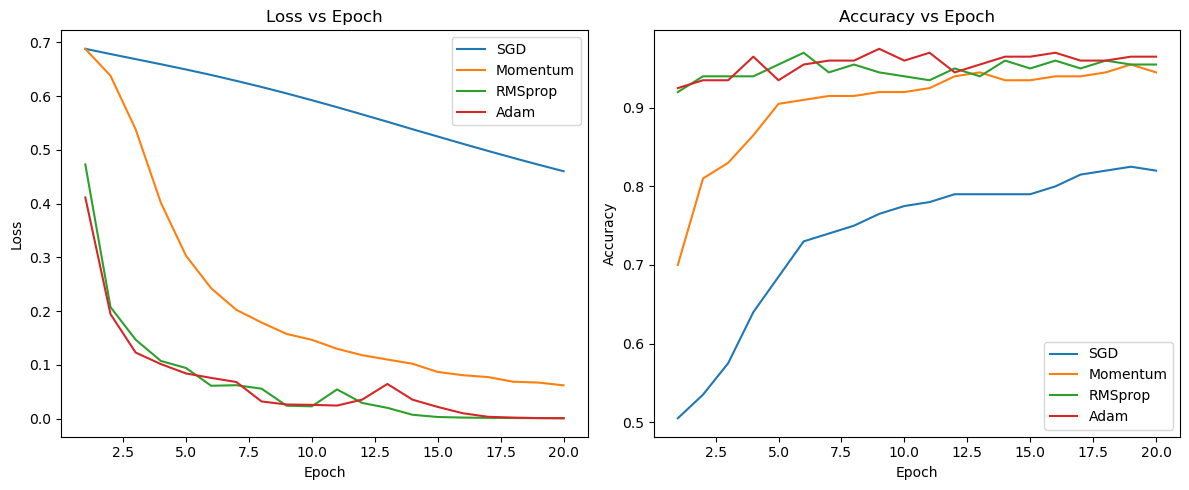

In [54]:
import matplotlib.pyplot as plt

optimizer_name = ["SGD", "Momentum", "RMSprop", "Adam"]
results = {}

for opt in optimizers:
    print(f"\nTraining with {opt}")
    model = SimpleNN()
    losses, accuracies = train_model(opt, model, train_loader, test_loader)
    results[opt] = {"loss": losses, "acc": accuracies}


epochs = range(1,21)

plt.figure(figsize = (12,5))

plt.subplot(1, 2, 1)
for opt in optimizers:
    plt.plot(epochs, results[opt]['loss'], label = opt)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for opt in optimizers:
    plt.plot(epochs, results[opt]['acc'], label = opt)
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()